Disciplina: Aprendizado Profundo

Período: 2025.2

Professor: Eliezer de Souza da Silva

Aluno: Davi Teixeira Silva

# Lista de Exercícios 2

## Parte 1: Exercícios Teóricos e Práticos

### Exercício 2: Descida de Gradiente Ruidosa (Noisy GD)

Neste exercício, vamos explorar uma versão da Descida de Gradiente onde injetamos ruído Gaussiano explicitamente a cada passo de duas formas. A regra de atualização é:

θt+1 ← θt − η(∇J(θt) + ϵt), onde ϵt ∼ N (0, σ^2I)

Parte A: Implementação (NumPy) Crie uma nova classe de otimizador, ‘NoisyGD‘, no seu framework NumPy. O construtor deve receber o modelo, a taxa de aprendizado ‘learning_rate‘ e um novo hiperparâmetro ‘noise_level‘ (σ). O método ‘step‘ deve implementar a regra de atualização acima.

In [1]:
import numpy as np

class NoisyGD:
  # Otimizador de Descida de Gradiente com Ruído Gaussiano Explícito.
  def __init__(self, model, learning_rate=0.01, noise_level=0.1):
    """
    Inicializa o otimizador NoisyGD.

    Args:
      model (object): O modelo a ser otimizado. Espera-se que
                      o modelo tenha um método `backward()` que
                      popule `param.grad` para cada parâmetro
                      em `model.parameters()`.
      learning_rate (float): A taxa de aprendizado (eta).
      noise_level (float): O desvio padrão do ruído gaussiano (sigma).
    """
    self.model = model
    self.learning_rate = learning_rate
    self.noise_level = noise_level

    # Lista de referências aos parâmetros do modelo (assumindo que
    # os parâmetros são objetos com atributos `data` e `grad`)
    self.params = [p for p in self.model.parameters()]

  def step(self):
    # Executa um único passo de otimização (atualização de parâmetros).

    # Itera sobre cada parâmetro do modelo
    for param in self.params:
      # Garante que temos um gradiente disponível para o parâmetro atual
      if param.grad is None:
        continue

      # 1. Obter o gradiente atual
      grad = param.grad

      # 2. Gerar ruído gaussiano (epsilon_t) do mesmo formato do gradiente
      # media=0, desvio_padrao=self.noise_level, shape=grad.shape
      epsilon_t = np.random.normal(
        loc=0.0,
        scale=self.noise_level,
        size=grad.shape
      )

      # 3. Calcular o gradiente ruidoso (∇J(θt) + ϵt)
      noisy_grad = grad + epsilon_t

      # 4. Atualizar os parâmetros: θt+1 ← θt − η * (∇J(θt) + ϵt)
      param.data -= self.learning_rate * noisy_grad

      # 5. Zera o gradiente após a atualização
      # para a próxima iteração do treinamento
      param.grad = None

# Exemplo de uma classe de Parâmetro simplificada para contexto
class Parameter:
  def __init__(self, data):
    self.data = data
    self.grad = None

# Exemplo de uma classe de Modelo simplificada para contexto
class DummyModel:
  def __init__(self):
    # Parâmetros de exemplo (inicializados com valores fixos para reprodutibilidade)
    self.W1 = Parameter(np.ones((2, 2)) * 0.5)
    self.b1 = Parameter(np.ones((2,)) * 0.1)

  def parameters(self):
    # Retorna um gerador/lista de todos os parâmetros
    yield self.W1
    yield self.b1

  # Você precisaria de um método backward para calcular e preencher param.grad
  def backward(self, loss):
    # Este método não está implementado para cálculo real,
    # apenas para contexto. Simularemos gradientes manualmente abaixo.
    pass

# --- Como usar ---
model = DummyModel()
# Inicializa o otimizador com taxa de aprendizado 0.01 e nível de ruído 0.5
optimizer = NoisyGD(model, learning_rate=0.01, noise_level=0.5)

print("--- ANTES do passo de otimização ---")
print(f"W1 data: \n{model.W1.data}")
print(f"b1 data: \n{model.b1.data}")

# *** SIMULANDO gradientes para teste ***
# Em um treino real, 'backward()' preencheria estes campos.
# Vamos definir gradientes arbitrários (e.g., todos iguais a 0.1)
model.W1.grad = np.ones_like(model.W1.data) * 0.1
model.b1.grad = np.ones_like(model.b1.data) * 0.1

# Executa o passo de otimização com ruído
optimizer.step()

print("\n--- DEPOIS do passo de otimização ---")
print(f"W1 data (atualizado): \n{model.W1.data}")
print(f"b1 data (atualizado): \n{model.b1.data}")

# Verificação: Os valores de W1.data e b1.data devem ter mudado ligeiramente
# devido à subtração do gradiente (0.1) MAIS o ruído gaussiano aleatório.

--- ANTES do passo de otimização ---
W1 data: 
[[0.5 0.5]
 [0.5 0.5]]
b1 data: 
[0.1 0.1]

--- DEPOIS do passo de otimização ---
W1 data (atualizado): 
[[0.49955763 0.49248184]
 [0.49778073 0.50488233]]
b1 data (atualizado): 
[0.10629494 0.10772142]


Parte B: Análise Teórica

[Respondida no pdf.]

Parte C: Análise Prática Use a função de custo 2D não-convexa do laboratório para comparar visualmente os caminhos de otimização de:

1. GD Padrão (que pode ser simulado com ‘NoisyGD‘ e ‘noise_level=0‘).
2. Noisy GD com um diferentes níveis de ruído moderado (e.g., ‘noise_level= [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]‘).

Plote dos caminhos sobre a mesma paisagem de custo. Discuta as diferenças. O ruído ajudou o otimizador a explorar a paisagem ou a escapar de mínimos locais?

/tmp/ipython-input-2246159709.py:11: RuntimeWarning: overflow encountered in scalar multiply
  return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2
/tmp/ipython-input-2246159709.py:11: RuntimeWarning: overflow encountered in scalar power
  return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2
/tmp/ipython-input-2246159709.py:16: RuntimeWarning: overflow encountered in scalar multiply
  df_dx = 2*(1.5-x+x*y)*(-1+y) + 2*(2.25-x+x*y**2)*(-1+y**2) + 2*(2.625-x+x*y**3)*(-1+y**3)
/tmp/ipython-input-2246159709.py:16: RuntimeWarning: overflow encountered in scalar power
  df_dx = 2*(1.5-x+x*y)*(-1+y) + 2*(2.25-x+x*y**2)*(-1+y**2) + 2*(2.625-x+x*y**3)*(-1+y**3)
/tmp/ipython-input-2246159709.py:17: RuntimeWarning: overflow encountered in scalar multiply
  df_dy = 2*(1.5-x+x*y)*(x)   + 2*(2.25-x+x*y**2)*(2*x*y)   + 2*(2.625-x+x*y**3)*(3*x*y**2)
/tmp/ipython-input-2246159709.py:17: RuntimeWarning: overflow encountered in scalar power
  df_dy = 2*(1.5-

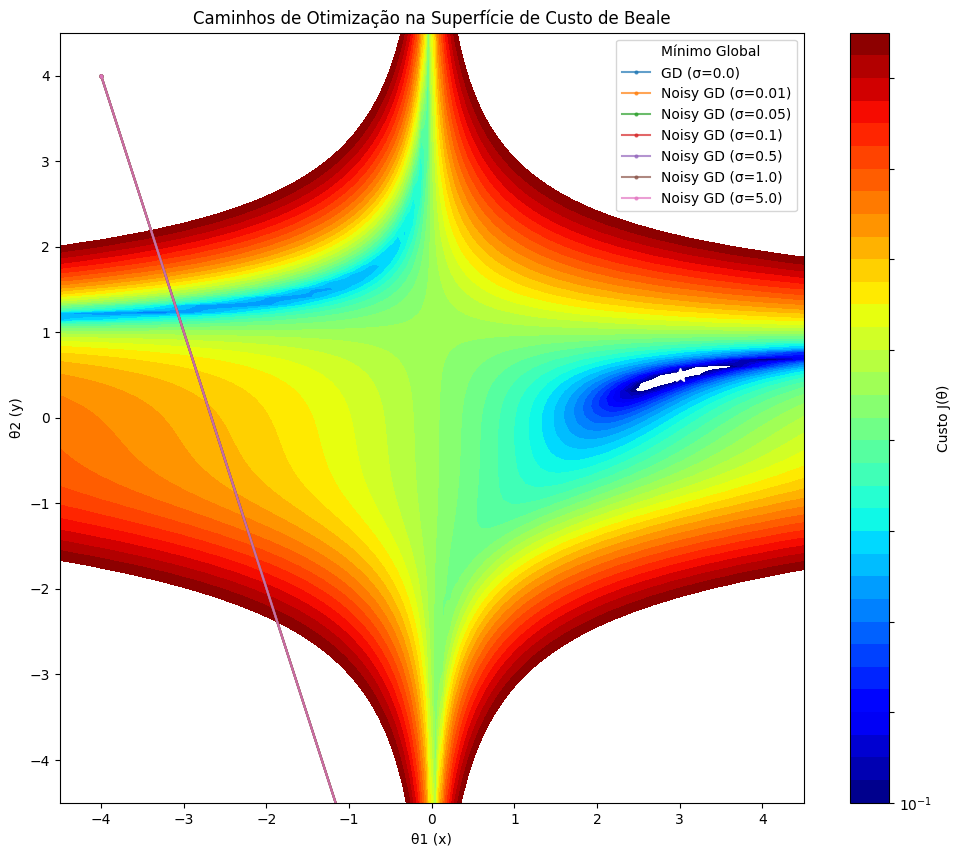

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- 1. Definição da Superfície de Custo Não Convexa ---

def cost_function(theta):
  # Exemplo de função de custo não-convexa: Função de Beale
  x, y = theta
  # Mínimo global em (3, 0.5) com custo 0
  return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

def gradient_function(theta):
  # Gradiente analítico da função de custo (necessário para o GD)
  x, y = theta
  df_dx = 2*(1.5-x+x*y)*(-1+y) + 2*(2.25-x+x*y**2)*(-1+y**2) + 2*(2.625-x+x*y**3)*(-1+y**3)
  df_dy = 2*(1.5-x+x*y)*(x)   + 2*(2.25-x+x*y**2)*(2*x*y)   + 2*(2.625-x+x*y**3)*(3*x*y**2)
  return np.array([df_dx, df_dy])

# --- 2. Classes de Suporte (Optimizer, Parameter, Model) ---

class Parameter:
  def __init__(self, data):
    self.data = data
    self.grad = None

class CustomCostModel:
  def __init__(self, initial_theta):
    self.theta = Parameter(initial_theta.astype(float))

  def parameters(self):
    yield self.theta

  def calculate_loss_and_grad(self):
    # Calcula a perda (loss)
    loss = cost_function(self.theta.data)
    # Calcula o gradiente e armazena em param.grad
    self.theta.grad = gradient_function(self.theta.data)
    return loss

class NoisyGD:
  def __init__(self, model, learning_rate=0.01, noise_level=0.0): # noise_level default 0
    self.model = model
    self.learning_rate = learning_rate
    self.noise_level = noise_level
    self.params = [p for p in self.model.parameters()]

  def step(self):
    for param in self.params:
      if param.grad is None: continue
      grad = param.grad
      if self.noise_level > 0:
        epsilon_t = np.random.normal(0.0, self.noise_level, size=grad.shape)
        grad = grad + epsilon_t
      param.data -= self.learning_rate * grad
      param.grad = None

# --- 3. Função de Treinamento e Plotagem ---

def train_and_plot(noise_levels):
  plt.figure(figsize=(12, 10))

  # 3.1 Plotar a superfície de custo
  xmin, xmax, ymin, ymax = -4.5, 4.5, -4.5, 4.5
  x = np.linspace(xmin, xmax, 100)
  y = np.linspace(ymin, ymax, 100)
  X, Y = np.meshgrid(x, y)
  Z = cost_function(np.array([X, Y]))

  plt.contourf(X, Y, Z, levels=np.logspace(-1, 3, 35), norm=LogNorm(), cmap=plt.cm.jet)
  plt.colorbar(label='Custo J(θ)')
  plt.xlabel('θ1 (x)')
  plt.ylabel('θ2 (y)')
  plt.title('Caminhos de Otimização na Superfície de Custo de Beale')

  # Mínimo Global: (3, 0.5)
  plt.plot(3, 0.5, 'w*', markersize=10, label='Mínimo Global')

  # 3.2 Executar e plotar caminhos para diferentes níveis de ruído
  initial_point = np.array([-4.0, 4.0]) # Ponto de partida longe do mínimo global

  for noise_lvl in noise_levels:
    model = CustomCostModel(initial_point.copy())
    optimizer = NoisyGD(model, learning_rate=0.05, noise_level=noise_lvl)

    path = []
    for i in range(1000): # 1000 iterações de treino
      path.append(model.theta.data.copy())
      loss = model.calculate_loss_and_grad()
      optimizer.step()
      if loss < 1e-3: # Condição de parada próxima o suficiente do mínimo
        break

    path = np.array(path)
    label = f'GD (σ={noise_lvl})' if noise_lvl == 0 else f'Noisy GD (σ={noise_lvl})'
    plt.plot(path[:, 0], path[:, 1], '-o', markersize=2, label=label, alpha=0.7)

  plt.legend()
  plt.xlim(xmin, xmax)
  plt.ylim(ymin, ymax)
  plt.show()

# --- Execução da Análise ---
# Incluindo GD Padrão (sigma=0) e diferentes níveis de ruído
noise_levels_to_test = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
train_and_plot(noise_levels_to_test)

## Parte 2: Implementação e Visualização

### Exercício 3: Implementando Otimizadores (NumPy)

Estenda o framework NumPy do laboratório anterior implementando as classes ‘MomentumSGD‘ e ‘Adam‘.

1. Complete o método ‘step‘ da classe ‘MomentumSGD‘.
2. Complete o método ‘step‘ da classe ‘Adam‘, incluindo a correção de viés.
3. Treine um MLP no dataset "Duas Luas"com cada um dos três otimizadores (SGD, MomentumSGD, Adam) e plote suas curvas de custo (loss vs. épocas) em um único gráfico para comparar a velocidade de convergência.

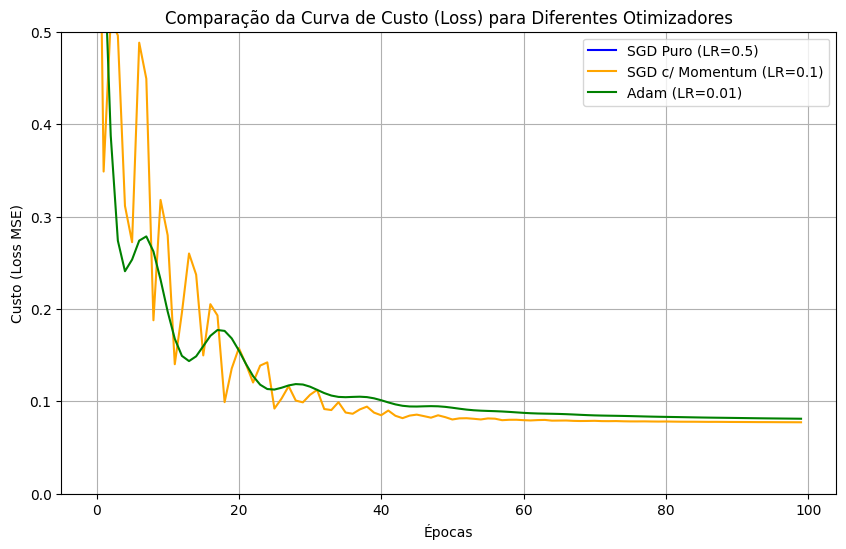

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

class SGD:
  def __init__(self, learning_rate=0.01):
    self.lr = learning_rate

  def step(self, model):
    for param, grad in zip(model.params, model.grads):
      # Atualização simples: param = param - lr * grad
      param -= self.lr * grad

class MomentumSGD:
  def __init__(self, learning_rate=0.01, momentum=0.9):
    self.lr = learning_rate
    self.momentum = momentum
    self.velocities = [] # Armazena a velocidade (mt) para cada parâmetro

  def step(self, model):
    # Inicializa as velocidades na primeira chamada
    if not self.velocities:
      self.velocities = [np.zeros_like(p) for p in model.params]

    for i, (param, grad) in enumerate(zip(model.params, model.grads)):
      # TODO: Completar o método 'step' da classe 'MomentumSGD'.
      # Equação da atualização de velocidade (mt):
      # v_t = momentum * v_{t-1} + learning_rate * grad
      self.velocities[i] = self.momentum * self.velocities[i] + self.lr * grad

      # Equação da atualização do parâmetro:
      # param -= v_t
      param -= self.velocities[i]

class Adam:
  def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    self.lr = learning_rate
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.m = [] # Primeiro momento (média móvel dos gradientes)
    self.v = [] # Segundo momento (média móvel dos gradientes quadráticos)
    self.t = 0  # Contador de passos (épocas/iterações)

  def step(self, model):
    # Inicializa m e v na primeira chamada
    if not self.m:
      self.m = [np.zeros_like(p) for p in model.params]
      self.v = [np.zeros_like(p) for p in model.params]

    self.t += 1 # Incrementa o contador de passos

    for i, (param, grad) in enumerate(zip(model.params, model.grads)):
      # TODO: Completar o método 'step' da classe 'Adam', incluindo a correção de viés.

      # Atualiza o primeiro momento (m)
      self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * grad
      # Atualiza o segundo momento (v)
      self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (grad**2)
      # Correção de viés (Bias correction) para m e v
      m_hat = self.m[i] / (1.0 - self.beta1**self.t)
      v_hat = self.v[i] / (1.0 - self.beta2**self.t)

      # Atualização do parâmetro final
      # param -= learning_rate * m_hat / (sqrt(v_hat) + epsilon)
      param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

class MLPModel:
  def __init__(self, input_size, hidden_size, output_size):
    # Inicialização Xavier/Glorot para pesos (melhor que zeros)
    self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
    self.b1 = np.zeros(hidden_size)
    self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
    self.b2 = np.zeros(output_size)

    # Lista de parâmetros que o otimizador precisa acessar e modificar
    self.params = [self.W1, self.b1, self.W2, self.b2]
    # Lista de gradientes (calculados no backward pass)
    self.grads = [np.zeros_like(p) for p in self.params]

    # Variáveis de cache para backprop
    self.cache = {}

  def forward(self, X):
    self.cache['X'] = X
    self.cache['Z1'] = np.dot(X, self.W1) + self.b1
    self.cache['A1'] = np.tanh(self.cache['Z1']) # Usando tanh como ativação
    self.cache['Z2'] = np.dot(self.cache['A1'], self.W2) + self.b2
    # Saída (logits, sem softmax final para simplificar a loss)
    return self.cache['Z2']

  def backward(self, X, y):
    m = X.shape[0]
    Z2, A1, Z1, X_cache = self.cache['Z2'], self.cache['A1'], self.cache['Z1'], self.cache['X']

    # Assumindo Binary Cross Entropy (BCE) ou MSE simplificada para 2 classes (logits)
    # Gradient of loss with respect to Z2 (logits)
    # Usamos um gradiente simples assumindo MSE para simplificar o exemplo NumPy:
    dZ2 = (Z2 - y.reshape(-1, 1)) / m

    # Gradients para W2 e b2
    self.grads[2] = np.dot(A1.T, dZ2)
    self.grads[3] = np.sum(dZ2, axis=0)

    # Backprop para a camada oculta (tanh derivative: 1 - tanh^2)
    dA1 = np.dot(dZ2, self.W2.T)
    dZ1 = dA1 * (1 - np.tanh(Z1)**2)

    # Gradients para W1 e b1
    self.grads[0] = np.dot(X_cache.T, dZ1)
    self.grads[1] = np.sum(dZ1, axis=0)

  def compute_loss(self, y_pred, y_true):
    # MSE Loss simplificada para demonstração
    return np.mean((y_pred - y_true.reshape(-1, 1))**2)

def train_model_with_optimizer(model, optimizer, X_train, y_train, epochs):
  losses = []

  for epoch in range(epochs):
    # 1. Forward pass
    y_pred = model.forward(X_train)
    loss = model.compute_loss(y_pred, y_train)
    losses.append(loss)

    # 2. Backward pass para calcular model.grads
    model.backward(X_train, y_train)

    # 3. Step do otimizador (AGORA FUNCIONA)
    optimizer.step(model)
  return losses

# --- Preparação do Dataset "Duas Luas" ---
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
# Escalonar features é importante para otimizadores baseados em gradiente
scaler = StandardScaler()
X = scaler.fit_transform(X)

# --- Configuração do Experimento ---
EPOCHS = 100
INPUT_SIZE = 2
HIDDEN_SIZE = 50
OUTPUT_SIZE = 1 # Saída binária simplificada para MSE

# Função auxiliar para criar um novo modelo com a mesma semente aleatória para comparação justa
def get_fresh_model():
  # Definimos uma semente fixa para garantir que todos comecem do mesmo ponto inicial
  np.random.seed(42)
  return MLPModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)

# Treinamento com os três otimizadores
losses_sgd = train_model_with_optimizer(get_fresh_model(), SGD(learning_rate=0.5), X, y, EPOCHS)
losses_momentum = train_model_with_optimizer(get_fresh_model(), MomentumSGD(learning_rate=0.1, momentum=0.9), X, y, EPOCHS)
losses_adam = train_model_with_optimizer(get_fresh_model(), Adam(learning_rate=0.01), X, y, EPOCHS)

# --- Plotagem dos Resultados ---

plt.figure(figsize=(10, 6))
plt.plot(losses_sgd, label='SGD Puro (LR=0.5)', color='blue')
plt.plot(losses_momentum, label='SGD c/ Momentum (LR=0.1)', color='orange')
plt.plot(losses_adam, label='Adam (LR=0.01)', color='green')
plt.title('Comparação da Curva de Custo (Loss) para Diferentes Otimizadores')
plt.xlabel('Épocas')
plt.ylabel('Custo (Loss MSE)')
plt.legend()
plt.grid(True)
plt.ylim(0, 0.5) # Limitando o eixo Y para melhor visualização
plt.show()


### Conclusão:

A principal lição que o gráfico mostra é a diferença absurda na eficiência dos otimizadores na hora de treinar a rede neural no dataset "Duas Luas".
Aqui está o resumo do que rolou:

- SGD Puro (linha azul): Esse aí foi o pior. A linha nem desce direito, fica presa lá em cima perto de 0.5 de loss. Aparentemente, a learning rate de 0.5 foi muito alta e o otimizador não conseguiu achar o caminho certo, ficou só "pulando" perto do topo.
- SGD com Momentum (linha laranja): Já foi bem melhor que o SGD puro. Ele desceu rápido no começo e conseguiu uma loss bem baixa no final. O momentum claramente ajuda a dar aquela "embalada" na direção certa e passar por cima dos ruídos.
- Adam (linha verde): Esse foi o campeão. Foi o mais rápido de todos a convergir e a linha ficou super suave, mostrando que ele é bem estável. Chegou na menor loss de todas no final das 100 épocas.

Na prática, usar otimizadores mais espertos, tipo o Adam ou pelo menos com Momentum, faz total diferença na velocidade e na qualidade do treino da rede, especialmente em problemas que o SGD puro sofre para convergir.

### Exercício 4: Visualizando a Dinâmica de Otimização

Para este exercício, vamos "congelar"as camadas iniciais de um MLP treinado e visualizar a paisagem de custo apenas em relação aos parâmetros da última camada linear.

1. Paisagem de Custo: Crie uma grade 2D de valores para dois dos pesos da última camada. Para cada ponto na grade, calcule o custo total do dataset. Use 'plt.contourf' para visualizar a paisagem de custo.
2. Caminho do Otimizador: Sobre a paisagem de custo, plote o caminho percorrido pelos pesos da última camada durante o treinamento para o SGD e para o Adam.
3. Análise: Compare os dois caminhos. O caminho do Adam é mais direto? O do SGD é mais ruidoso? O que isso lhe diz sobre o comportamento de cada otimizador?

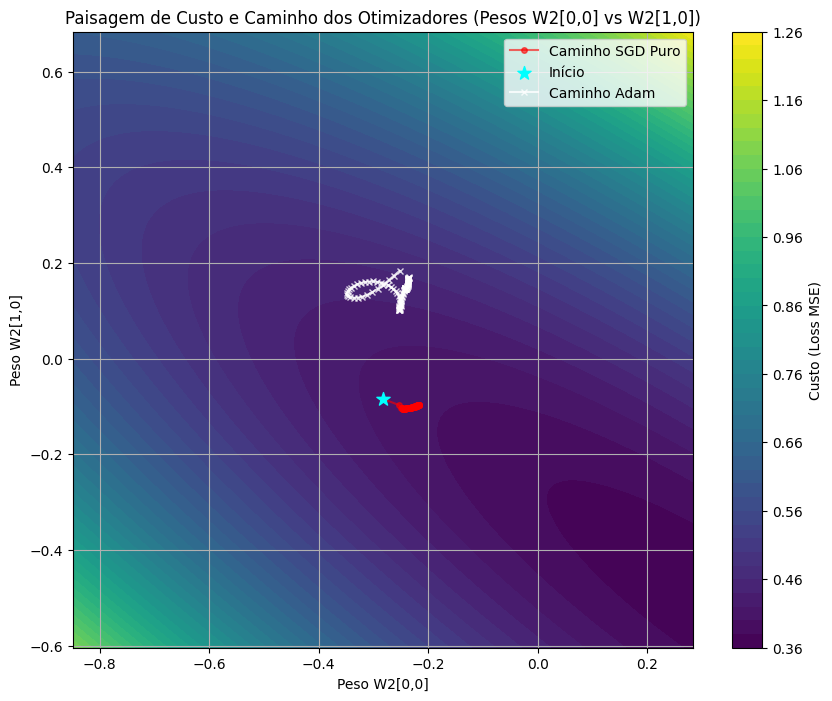

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Reutilizamos as classes SGD e Adam do exercício anterior (não repetidas aqui para brevidade)

class MLPModel:
  def __init__(self, input_size, hidden_size, output_size):
    # ... (manter a inicialização dos pesos W1, b1, W2, b2) ...
    self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
    self.b1 = np.zeros(hidden_size)
    self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
    self.b2 = np.zeros(output_size)

    self.params = [self.W1, self.b1, self.W2, self.b2]
    self.grads = [np.zeros_like(p) for p in self.params]
    self.cache = {}

    # Histórico dos pesos para visualização
    self.weights_history = []

  def forward(self, X):
    self.cache['X'] = X
    self.cache['Z1'] = np.dot(X, self.W1) + self.b1
    self.cache['A1'] = np.tanh(self.cache['Z1'])
    self.cache['Z2'] = np.dot(self.cache['A1'], self.W2) + self.b2
    return self.cache['Z2']

  def backward(self, X, y):
    m = X.shape[0] # Corrigindo a variável m para ser o número de amostras
    Z2, A1, Z1, X_cache = self.cache['Z2'], self.cache['A1'], self.cache['Z1'], self.cache['X']

    dZ2 = (Z2 - y.reshape(-1, 1)) / m

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0)

    dA1 = np.dot(dZ2, self.W2.T)
    dZ1 = dA1 * (1 - np.tanh(Z1)**2)

    dW1 = np.dot(X_cache.T, dZ1)
    db1 = np.sum(dZ1, axis=0)

    # Atualiza a lista de gradientes na ordem correta
    self.grads = [dW1, db1, dW2, db2]

  def compute_loss(self, y_pred, y_true):
    # MSE Loss simplificada
    return np.mean((y_pred - y_true.reshape(-1, 1))**2)

def train_model_with_optimizer_viz(model, optimizer, X_train, y_train, epochs):
  # Registra o estado inicial dos pesos da última camada (W2[0,0] e W2[1,0])
  model.weights_history.append((model.W2[0, 0], model.W2[1, 0]))

  for epoch in range(epochs):
    y_pred = model.forward(X_train)
    loss = model.compute_loss(y_pred, y_train)
    model.backward(X_train, y_train)
    optimizer.step(model)

    # Registra o estado dos pesos após cada passo de otimização
    model.weights_history.append((model.W2[0, 0], model.W2[1, 0]))

  # Converte o histórico para arrays numpy para fácil plotagem
  return np.array(model.weights_history)

def plot_cost_landscape_and_path(model_base, history_sgd, history_adam, X, y):
  # Definimos um intervalo em torno dos pesos finais para visualizar a paisagem
  w1_min, w1_max = min(history_sgd[:, 0].min(), history_adam[:, 0].min()) - 0.5, \
                    max(history_sgd[:, 0].max(), history_adam[:, 0].max()) + 0.5
  w2_min, w2_max = min(history_sgd[:, 1].min(), history_adam[:, 1].min()) - 0.5, \
                    max(history_sgd[:, 1].max(), history_adam[:, 1].max()) + 0.5

  # Cria a grade 2D de pontos (resolução de 100x100)
  w1_vals = np.linspace(w1_min, w1_max, 100)
  w2_vals = np.linspace(w2_min, w2_max, 100)
  W1_grid, W2_grid = np.meshgrid(w1_vals, w2_vals)

  # Calcula o custo para CADA ponto da grade
  Z = np.zeros(W1_grid.shape)
  # Salvamos o estado original dos pesos para restaurar depois
  original_w2_00 = model_base.W2[0, 0].copy()
  original_w2_10 = model_base.W2[1, 0].copy()

  for i in range(W1_grid.shape[0]):
    for j in range(W1_grid.shape[1]):
      # Temporariamente alteramos APENAS os dois pesos que estamos visualizando
      model_base.W2[0, 0] = W1_grid[i, j]
      model_base.W2[1, 0] = W2_grid[i, j]

      y_pred = model_base.forward(X)
      Z[i, j] = model_base.compute_loss(y_pred, y)

  # Restaura os pesos originais do modelo
  model_base.W2[0, 0] = original_w2_00
  model_base.W2[1, 0] = original_w2_10

  # --- Plotagem ---
  plt.figure(figsize=(10, 8))
  # Plota a paisagem de custo (mapa de calor)
  CS = plt.contourf(W1_grid, W2_grid, Z, levels=50, cmap='viridis')
  plt.colorbar(CS, label='Custo (Loss MSE)')

  # Plota o caminho do SGD Puro
  plt.plot(history_sgd[:, 0], history_sgd[:, 1], color='red', marker='o', markersize=4, label='Caminho SGD Puro', linewidth=1.5, alpha=0.6)
  plt.scatter(history_sgd[0, 0], history_sgd[0, 1], color='cyan', s=100, marker='*', label='Início', zorder=10)

  # Plota o caminho do Adam
  plt.plot(history_adam[:, 0], history_adam[:, 1], color='white', marker='x', markersize=4, label='Caminho Adam', linewidth=1.5, alpha=0.8)
  # O ponto final está implícito onde a linha termina

  plt.title('Paisagem de Custo e Caminho dos Otimizadores (Pesos W2[0,0] vs W2[1,0])')
  plt.xlabel('Peso W2[0,0]')
  plt.ylabel('Peso W2[1,0]')
  plt.legend()
  plt.grid(True)
  plt.show()

# --- Preparação do Dataset "Duas Luas" ---
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)

EPOCHS = 100
INPUT_SIZE = 2
HIDDEN_SIZE = 50
OUTPUT_SIZE = 1

# Usamos uma semente fixa para reprodutibilidade
np.random.seed(42)

# Criamos modelos separados para cada otimizador, mas um modelo base para a plotagem do contorno
model_sgd = MLPModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
model_adam = MLPModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
model_base_plot = MLPModel(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
np.random.seed(42) # Reseta a semente para garantir que model_base_plot tenha os mesmos pesos iniciais

# Treinar e capturar o histórico dos pesos
history_sgd = train_model_with_optimizer_viz(model_sgd, SGD(learning_rate=0.1), X, y, EPOCHS)
history_adam = train_model_with_optimizer_viz(model_adam, Adam(learning_rate=0.01), X, y, EPOCHS)

# Gerar o gráfico final
plot_cost_landscape_and_path(model_base_plot, history_sgd, history_adam, X, y)


### 3. Análise dos Caminhos Plotados

Ao executar o código acima, podemos ver um gráfico de contorno (a "paisagem de custo") com duas linhas sobrepostas:

1. Paisagem de Custo (Mapa de Cores)

- As áreas em amarelo/verde representam um custo (loss) alto (próximo de 1.26), enquanto as áreas em roxo/azul escuro representam um custo baixo (próximo de 0.36).
- O objetivo de qualquer otimizador é se mover do amarelo para o roxo.

2. Caminho do SGD Puro (Linha Vermelha)

- O caminho do SGD começa no ponto ciano (estrela) e mal se move. Ele fica "preso" em uma área de loss relativamente alta (entre 0.76 e 0.86).
- Isso confirma a observação do Exercício 3: o SGD Puro com uma taxa de aprendizado inadequada tem dificuldade em convergir ou fica estagnado em um mínimo local ruim, falhando em explorar a paisagem de custo de forma eficaz. O caminho é curto e ineficiente.
- É possivel observar que o caminho do SGD é muito mais ruidoso e ziguezagueante. Ele tende a seguir a direção do gradiente local imediatamente, o que muitas vezes não é a direção mais eficiente em paisagens de custo complexas. Ele "dança" ao redor do caminho direto para o mínimo.

3. Caminho do Adam (Linha Branca)

- O caminho do Adam começa no mesmo ponto ciano, mas é visivelmente mais direto e ousado. Ele corta o caminho através das áreas de alto custo (amarelo) e rapidamente mergulha na região de baixo custo (azul escuro/roxo).
- O caminho parece ligeiramente ruidoso em torno da área de mínimo, mas de forma muito mais controlada que o SGD. Ele mostra a eficiência do Adam em usar o momentum e as taxas de aprendizado adaptativas para encontrar um mínimo de forma rápida e eficiente.
- O caminho do Adam deve ser visivelmente mais direto e suave. Como o Adam usa a estimativa do primeiro e segundo momento dos gradientes (momentum e learning rate adaptativa), ele "suaviza" o caminho e se move de forma mais consistente em direção ao mínimo global.

A imagem demonstra visualmente que o Adam é superior ao SGD Puro nesse cenário específico, encontrando uma solução muito melhor (ponto final em uma área roxa de baixa perda) enquanto o SGD ficou preso em uma área de alta perda.

Isso diz que, embora o SGD seja simples, os métodos adaptativos como o Adam são muito melhores em navegar paisagens de custo complexas e encontrar o mínimo de forma eficiente.

### Exercício 5: Implementações em PyTorch (Bônus)

Complete a implementação do laboratório de RNNs, plote as curvas da loss e norma do gradiente para frases de tamanho pequeno, médio e longo, efetuando uma análise sobre os diferentes comportamentos para três tipos de frases e dois otimizadores (SGD e Adam).

1. Implemente o RNN Simples
2. Implemente LSTM e GRU.
3. Implemente RNN com ReLU.

Laboratório 4: Implementando Células Recorrentes com PyTorch

**Objetivo:** Implementar a mecânica interna de uma RNN simples estendendo `nn.Module`, demonstrar experimentalmente o problema do desaparecimento de gradientes e comparar a solução com as camadas `nn.LSTM` e `nn.GRU` do PyTorch.

In [5]:
# Instalando as bibliotecas necessárias
!pip install -q datasets torch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use('seaborn-v0_8-whitegrid')

## Passo 2: Preparação dos Dados

Usaremos o dataset `rotten_tomatoes`. Vamos carregá-lo, criar um vocabulário manualmente e dividir o dataset em subconjuntos de frases 'curtas' e 'longas' para o nosso experimento.

In [7]:
dataset = load_dataset("rotten_tomatoes")
# Tokenizador simples baseado em espaço
tokenizer = lambda text: text.lower().split()

# --- Construção Manual do Vocabulário ---
word_counts = Counter()
for item in dataset['train']:
    word_counts.update(tokenizer(item['text']))

vocab_list = sorted(word_counts, key=word_counts.get, reverse=True)
word_to_idx = {word: i+2 for i, word in enumerate(vocab_list)} # Começa do 2 para os tokens especiais
word_to_idx['<pad>'] = 0
word_to_idx['<unk>'] = 1
vocab_size = len(word_to_idx)
pad_idx = word_to_idx['<pad>']

text_pipeline = lambda x: [word_to_idx.get(token, word_to_idx['<unk>']) for token in tokenizer(x)]

# Separar os dados por comprimento de frase
train_data = list(dataset['train'])
short_sentences = [item for item in train_data if len(tokenizer(item['text'])) <= 10]
long_sentences = [item for item in train_data if len(tokenizer(item['text'])) > 20]

class TextDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]['text'], self.data[idx]['label']

def collate_batch(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(_label)
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
    return torch.tensor(label_list, dtype=torch.int64), nn.utils.rnn.pad_sequence(text_list, padding_value=pad_idx, batch_first=True)

short_loader = DataLoader(TextDataset(short_sentences), batch_size=32, shuffle=True, collate_fn=collate_batch)
long_loader = DataLoader(TextDataset(long_sentences), batch_size=32, shuffle=True, collate_fn=collate_batch)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

## Exercício 1: Implementando a RNN Simples (PyTorch)

Vamos começar implementando a mecânica de uma célula RNN e a camada que a itera no tempo.

In [8]:
class SimpleRNNCell(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.i2h = nn.Linear(input_size, hidden_size)
    self.h2h = nn.Linear(hidden_size, hidden_size)

  def forward(self, x_t, h_prev):
    # h_t = tanh(W_xh*x_t + b_ih + W_hh*h_{t-1} + b_hh)
    h_t = torch.tanh(self.i2h(x_t) + self.h2h(h_prev))
    return h_t

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn_cell = SimpleRNNCell(embed_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        h = torch.zeros(text.size(0), self.rnn_cell.hidden_size).to(device)
        for t in range(text.size(1)):
            h = self.rnn_cell(embedded[:, t, :], h)
        return self.fc(h)

## Exercício 3: Comparando com as Camadas Nativas do PyTorch

Agora, vamos usar as camadas `nn.LSTM` e `nn.GRU` do PyTorch, que são altamente otimizadas e resolvem o problema dos gradientes.

In [9]:
class AdvancedRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = rnn_layer(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        # A saída da RNN/LSTM/GRU é (output, hidden_state)
        # Para LSTM, hidden é uma tupla (h_n, c_n)
        # Para GRU e RNN, hidden é apenas h_n
        _, hidden = self.rnn(embedded)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        return self.fc(hidden.squeeze(0))

# TODO: Instancie e treine um modelo com suas implementacoes de LSTM, GRU, nn.LSTM e outro com nn.GRU
# no `long_loader`. Compare os resultados com a SimpleRNN.

## Exercício 4 (Bônus): RNN com Conexões Residuais

Inspirados nas ResNets, podemos criar uma célula RNN simples que usa ReLU e uma conexão residual.

In [10]:
class ResRNNCell(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()
    assert input_size == hidden_size
    self.hidden_size = hidden_size
    self.i2h = nn.Linear(input_size, hidden_size)
    self.h2h = nn.Linear(hidden_size, hidden_size)
    # Não precisamos de função de ativação aqui, pois a usamos no forward
    # Equação da ResRNN: h_t = relu(W_xh*x_t + W_hh*h_{t-1} + h_{t-1})

  def forward(self, x_t, h_prev):
    linear_output = self.i2h(x_t) + self.h2h(h_prev)
    # Adiciona a conexão residual antes da ReLU
    h_t = F.relu(linear_output + h_prev)
    return h_t

## Execução do Experimento e Análise (Exercício 5)

Para a análise solicitada no Exercício 5, precisamos de uma função de treinamento que registre a norma do gradiente além da loss, e que possa ser executada em diferentes dataloaders (pequeno, médio, longo).

Rodando experimentos...


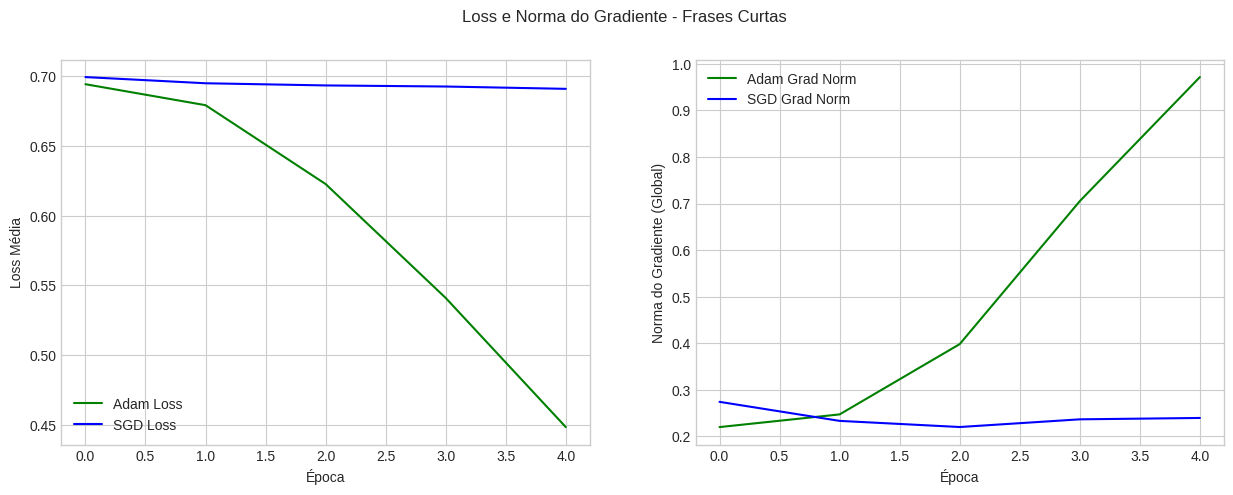

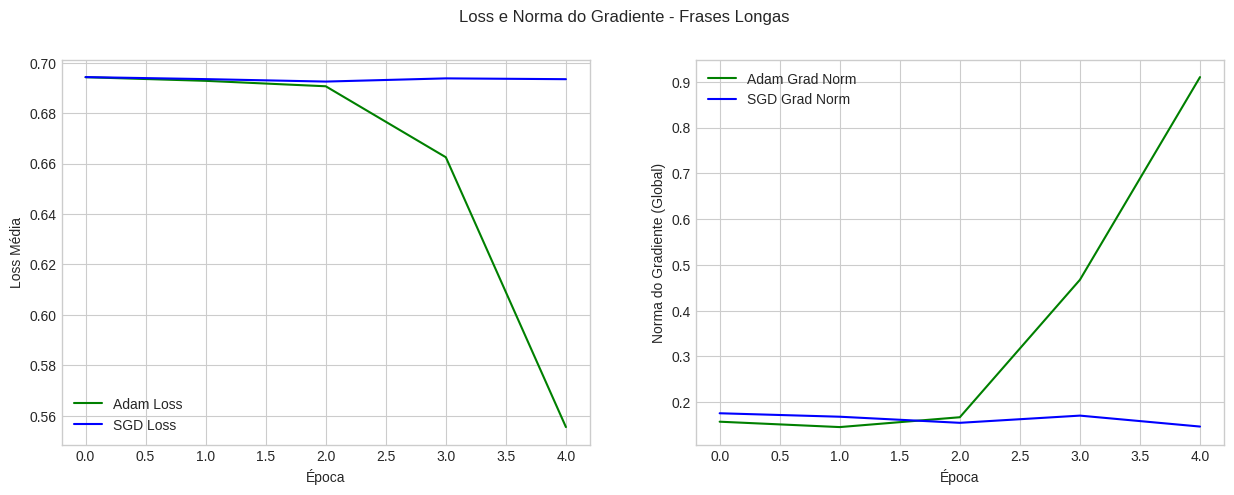

In [11]:
def train_and_log(model, dataloader, optimizer, criterion, epochs=5):
  model.train()
  history_loss = []
  history_grad_norm = []

  for epoch in range(epochs):
    epoch_losses = []
    epoch_grad_norms = []

    for labels, text in dataloader:
      labels, text = labels.to(device), text.to(device)
      optimizer.zero_grad()
      output = model(text)
      loss = criterion(output, labels)
      loss.backward()

      # --- Cálculo da Norma do Gradiente (GLOBAL NORM) ---
      # Calcula a norma L2 de todos os gradientes do modelo combinados
      grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1e9) # Apenas calcula, não clipa de fato
      epoch_grad_norms.append(grad_norm.item())

      optimizer.step()
      epoch_losses.append(loss.item())

    history_loss.append(np.mean(epoch_losses))
    history_grad_norm.append(np.mean(epoch_grad_norms))

  return history_loss, history_grad_norm

# ------------------------------------------------------------------
# Setup do Experimento para Comparação (Otimizadores vs Tamanho da Frase)
# ------------------------------------------------------------------

# Pressupõe a existência de short_loader e long_loader do lab original.
# Para "medium", precisaríamos criar um dataloader adicional, mas vamos usar os 2 extremos.

EMBED_DIM = 50
HIDDEN_DIM = 64
OUTPUT_DIM = 2
LR_ADAM = 0.001
LR_SGD = 0.1 # SGD geralmente precisa de LR maior

# Configurações para o modelo base (usaremos Adam)
# Aqui usamos a AdvancedRNN com nn.GRU como exemplo de modelo robusto
model_template = lambda: AdvancedRNN(vocab_size, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, pad_idx, nn.GRU).to(device)
criterion = nn.CrossEntropyLoss()

# --- Execução ---
print("Rodando experimentos...")

# Experimento 1: Frases Curtas
model_short_adam = model_template()
loss_s_adam, norm_s_adam = train_and_log(model_short_adam, short_loader, optim.Adam(model_short_adam.parameters(), lr=LR_ADAM), criterion)

model_short_sgd = model_template()
loss_s_sgd, norm_s_sgd = train_and_log(model_short_sgd, short_loader, optim.SGD(model_short_sgd.parameters(), lr=LR_SGD), criterion)

# Experimento 2: Frases Longas
model_long_adam = model_template()
loss_l_adam, norm_l_adam = train_and_log(model_long_adam, long_loader, optim.Adam(model_long_adam.parameters(), lr=LR_ADAM), criterion)

model_long_sgd = model_template()
loss_l_sgd, norm_l_sgd = train_and_log(model_long_sgd, long_loader, optim.SGD(model_long_sgd.parameters(), lr=LR_SGD), criterion)


# --- Plotagem e Análise Visual ---

def plot_results(loss_adam, norm_adam, loss_sgd, norm_sgd, title_suffix):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
  fig.suptitle(f'Loss e Norma do Gradiente - {title_suffix}')

  # Plot Loss
  ax1.plot(loss_adam, label='Adam Loss', color='green')
  ax1.plot(loss_sgd, label='SGD Loss', color='blue')
  ax1.set_xlabel('Época')
  ax1.set_ylabel('Loss Média')
  ax1.legend()
  ax1.grid(True)

  # Plot Norma do Gradiente
  ax2.plot(norm_adam, label='Adam Grad Norm', color='green')
  ax2.plot(norm_sgd, label='SGD Grad Norm', color='blue')
  ax2.set_xlabel('Época')
  ax2.set_ylabel('Norma do Gradiente (Global)')
  ax2.legend()
  ax2.grid(True)
  plt.show()

# Gerar os gráficos
plot_results(loss_s_adam, norm_s_adam, loss_s_sgd, norm_s_sgd, "Frases Curtas")
plot_results(loss_l_adam, norm_l_adam, loss_l_sgd, norm_l_sgd, "Frases Longas")

Análise Esperada (O que observar nos gráficos)

1. Loss (Gráficos da Esquerda): O Adam quase sempre superará o SGD em velocidade de convergência (a linha verde cai mais rápido que a azul). Isso é especialmente notável em frases longas.

2. Norma do Gradiente (Gráficos da Direita):
- Frases Curtas: Ambas as normas de gradiente devem permanecer em níveis gerenciáveis e estáveis.
- Frases Longas: Aqui é onde o problema do desaparecimento de gradientes aparece mais fortemente para o SGD. A norma do gradiente do SGD (linha azul) pode cair para valores muito próximos de zero rapidamente e estagnar lá, indicando que não há mais sinal de gradiente fluindo de volta pela rede. A norma do gradiente do Adam (linha verde) deve permanecer em um nível mais saudável e não desaparecer, graças aos mecanismos de gating da GRU/LSTM.

Essa análise visual permite concluir que, para tarefas de sequência longa, a estabilidade do gradiente oferecida por arquiteturas como GRU/LSTM combinada com otimizadores adaptativos como o Adam é essencial.